# Clean Trajectory Inference: CD8 and CD4, pre and post

This notebook creates a single multi-panel trajectory figure with 4 rows and 3 columns:

- `CD8 pre`: Monocle3, PAGA, Slingshot
- `CD8 post`: Monocle3, PAGA, Slingshot
- `CD4 pre`: Monocle3, PAGA, Slingshot
- `CD4 post`: Monocle3, PAGA, Slingshot

The main parameters to adjust are in the config cell below, especially `start_node` for Slingshot if the cluster numbering changes after preprocessing.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import patchworklib as pw

import methods as mt


<Figure size 100x100 with 0 Axes>

In [2]:
adata = sc.read_h5ad("/home/roger/data_itx/adata_all.h5ad")
adata


AnnData object with n_obs × n_vars = 23872 × 18347
    obs: 'patient', 'treatment', 'cluster', 'UMAP1', 'UMAP2', 'celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
palette_cd8 = {
    "CD8_naive": "skyblue",
    "CD8_mem": "green",
    "CD8_ex": "red",
    "CD8_ex_act": "purple",
    "CD8_eff": "navy",
    "CD8_act": "gold",
}

palette_cd4 = {
    "Naive": "#4C72B0",
    "Tfh": "#DD8452",
    "Th17": "#55A868",
    "Treg": "#C44E52",
}

cd8_clusters = ["CD8_ex", "CD8_mem", "CD8_eff", "CD8_naive", "CD8_ex_act", "CD8_act"]
cd4_clusters = ["Naive", "Tfh", "Th17", "Treg"]


In [4]:
panel_specs = [
    {
        "row_name": "CD8 pre",
        "label_prefix": "cd8_pre",
        "clusters": cd8_clusters,
        "treatment": "pre",
        "palette": palette_cd8,
        "root_celltype": "CD8_naive",
        "start_node": 4,
    },
    {
        "row_name": "CD8 post",
        "label_prefix": "cd8_post",
        "clusters": cd8_clusters,
        "treatment": "post",
        "palette": palette_cd8,
        "root_celltype": "CD8_naive",
        "start_node": 4,
    },
    {
        "row_name": "CD4 pre",
        "label_prefix": "cd4_pre",
        "clusters": cd4_clusters,
        "treatment": "pre",
        "palette": palette_cd4,
        "root_celltype": "Naive",
        "start_node": 0,
    },
    {
        "row_name": "CD4 post",
        "label_prefix": "cd4_post",
        "clusters": cd4_clusters,
        "treatment": "post",
        "palette": palette_cd4,
        "root_celltype": "Naive",
        "start_node": 0,
    },
]

#panel_specs


In [5]:
def subset_cells(adata, clusters, treatment):
    subset = adata[adata.obs["celltype"].isin(clusters)].copy()
    subset = subset[subset.obs["treatment"] == treatment].copy()
    return subset


def preprocess_subset(adata_subset, n_comps=16, n_pcs=16, resolution=0.7, min_dist=0.3): # before 0.3
    adata_subset = adata_subset.copy()
    sc.tl.pca(adata_subset, n_comps=n_comps)
    sc.pp.neighbors(adata_subset, n_pcs=n_pcs)
    sc.tl.leiden(adata_subset, resolution=resolution)
    sc.tl.umap(adata_subset, min_dist=min_dist)
    return adata_subset


def build_trajectory_row(adata_subset, palette, root_celltype, start_node, row_name, label_prefix, brick_figsize=(3.8, 3.4)):
    monocle_ax = pw.Brick(f"{label_prefix}_monocle3", figsize=brick_figsize)
    paga_ax = pw.Brick(f"{label_prefix}_paga", figsize=brick_figsize)
    slingshot_ax = pw.Brick(f"{label_prefix}_slingshot", figsize=brick_figsize)

    mt.monocle3(
        adata_subset.copy(),
        palette_cd8=palette,
        ax=monocle_ax,
        title=f"{row_name} | Monocle3",
        show=False,
    )
    mt.run_paga(
        adata_subset.copy(),
        root_celltype=root_celltype,
        ax=paga_ax,
        title=f"{row_name} | PAGA",
        show=False,
    )
    mt.run_slingshot(
        adata_subset.copy(),
        start_node=start_node,
        ax=slingshot_ax,
        title=f"{row_name} | Slingshot",
        show=False,
    )

    return monocle_ax | paga_ax | slingshot_ax


In [6]:
prepared = {}
summary_rows = []

for spec in panel_specs:
    subset = subset_cells(adata, spec["clusters"], spec["treatment"])
    prepared_subset = preprocess_subset(subset)
    prepared[spec["row_name"]] = prepared_subset
    summary_rows.append({
        "row_name": spec["row_name"],
        "n_cells": prepared_subset.n_obs,
        "celltypes": sorted(prepared_subset.obs["celltype"].unique().tolist()),
    })

pd.DataFrame(summary_rows)


,row_name,n_cells,celltypes
0,CD8 pre,7014,"[CD8_act, CD8_eff, CD8_ex, CD8_ex_act, CD8_mem..."
1,CD8 post,7371,"[CD8_act, CD8_eff, CD8_ex, CD8_ex_act, CD8_mem..."
2,CD4 pre,5839,"[Naive, Tfh, Th17, Treg]"
3,CD4 post,3648,"[Naive, Tfh, Th17, Treg]"


Lineages: [Lineage[4, 1], Lineage[4, 2, 0, 3], Lineage[4, 5]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @4 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff42c27a210>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff42c27a0d0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff42c270ad0>]
Shrinking branch @4 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff42c27a210>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff42c27a0d0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff42c270ad0>]
Lineages: [Lineage[4, 1, 2, 3, 0], Lineage[4, 5]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @4 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40ba4f9b0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40b9e36f0>]
Shrinking branch @4 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40ba4f9b0>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40b9e36f0>]
Lineages: [Lineage[0, 1, 2], Lineage[0, 3]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @0 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40a72f020>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40b9ff450>]
Shrinking branch @0 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40a72f020>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40b9ff450>]
Lineages: [Lineage[0, 1, 3], Lineage[0, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @0 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40bbcbd40>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40bbcae40>]
Shrinking branch @0 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40bbcbd40>, <pcurvepy2.pcurve.PrincipalCurve object at 0x7ff40bbcae40>]


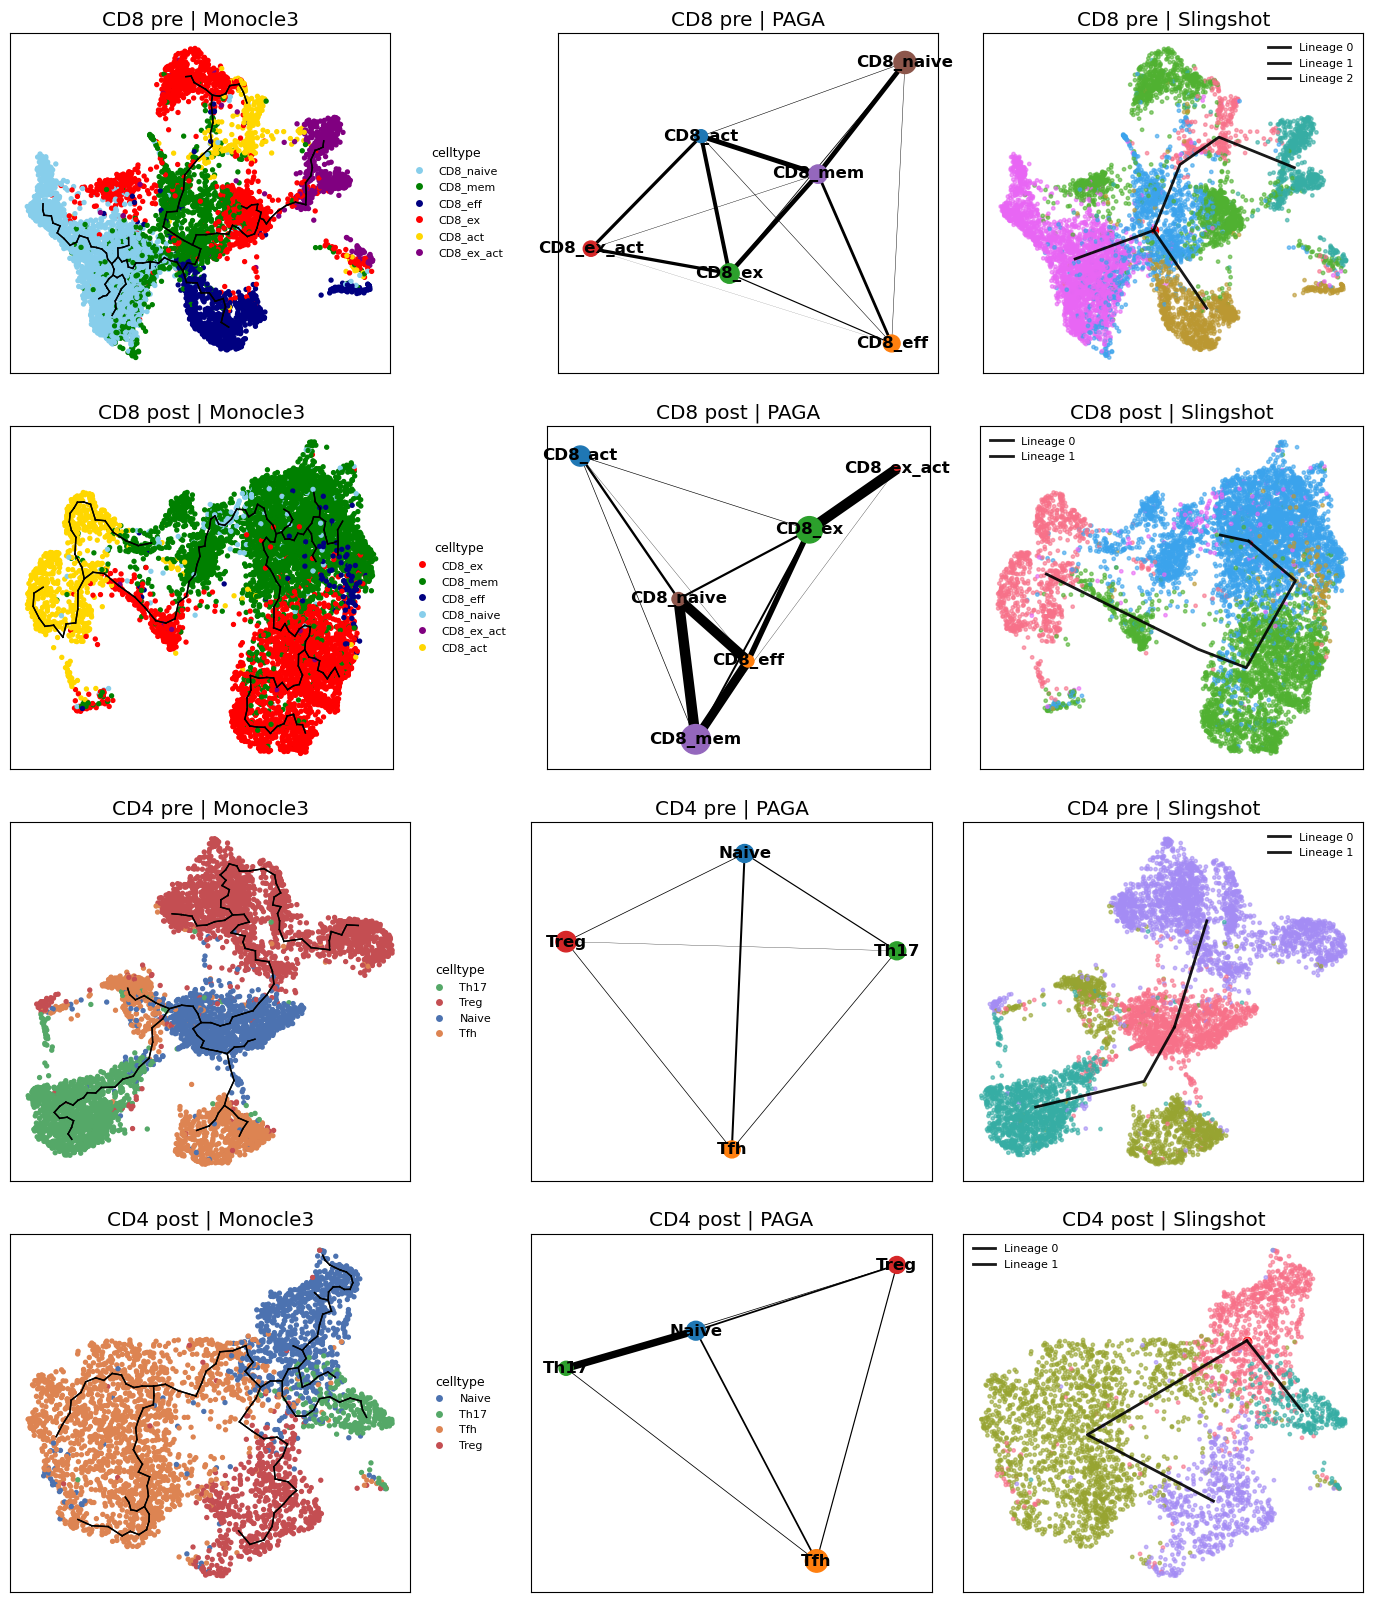

<Figure size 640x480 with 0 Axes>

In [7]:
pw.param["margin"] = 0.3

rows = []
for spec in panel_specs:
    row = build_trajectory_row(
        prepared[spec["row_name"]],
        palette=spec["palette"],
        root_celltype=spec["root_celltype"],
        start_node=spec["start_node"],
        row_name=spec["row_name"],
        label_prefix=spec["label_prefix"],
    )
    rows.append(row)

canvas = rows[0]
for row in rows[1:]:
    canvas = canvas / row

canvas.savefig()


In [8]:
output_png = "/home/roger/Itx_anl/Itx_anl/methods/trajectory_cd4_cd8_pre_post_clean_final.png"
canvas.savefig(output_png)
output_png


'/home/roger/Itx_anl/Itx_anl/methods/trajectory_cd4_cd8_pre_post_clean_final.png'